<a href="https://colab.research.google.com/github/B-Pearlraj/Driver_Drowsiness_DL/blob/main/Drowsiness_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Project:5 Driver Drowsiness Detection using Eye Closure and Yawning Analysis with Deep Learning**

## **Step 1 — Problem Understanding**

Driver fatigue can reduce alertness, reaction time and decision-making ability. This project uses facial physiological indicators:

1. Eye closure
2. Yawning

The system is implemented as an image-based deep-learning solution and combines eye and mouth predictions into three fatigue levels.


## **Step 2 — Dataset Collection**

The supplied project specification requires four classes:

- `open`
- `closed`
- `yawn`
- `no_yawn`




In [ ]:
# 2.1 Imports and reproducibility
import os
import shutil
import random
import time
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## **Step 3 — Dataset Organization**



```text
split_dataset/
├── train/
│   ├── closed/
│   ├── open/
│   ├── yawn/
│   └── no_yawn/
├── validation/
│   ├── closed/
│   ├── open/
│   ├── yawn/
│   └── no_yawn/
└── test/
    ├── closed/
    ├── open/
    ├── yawn/
    └── no_yawn/
```

The split is 70% training, 15% validation and 15% test for each class.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 3.1 Paths
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL"
)

SOURCE_DIR = PROJECT_ROOT / "archive" / "train"
SPLIT_DIR = PROJECT_ROOT / "archive" / "split_dataset"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Map expected class names to possible source-folder spellings.
SOURCE_CLASS_MAP = {
    "closed": ["closed", "Closed"],
    "open": ["open", "Open"],
    "yawn": ["yawn", "Yawn"],
    "no_yawn": ["no_yawn", "No_Yawn", "no yawn", "No Yawn"]
}

EXPECTED_CLASSES = ["closed", "open", "yawn", "no_yawn"]

def resolve_class_folder(source_dir, candidates):
    for name in candidates:
        folder = source_dir / name
        if folder.exists() and folder.is_dir():
            return folder
    return None

print("Source directory:", SOURCE_DIR)
print("Exists:", SOURCE_DIR.exists())


Source directory: /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train
Exists: True


In [ ]:
# 3.2 Build a clean 70/15/15 split
def image_files(folder):
    return sorted(
        [
            p for p in folder.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]
    )

resolved_source_folders = {}

for cls in EXPECTED_CLASSES:
    folder = resolve_class_folder(SOURCE_DIR, SOURCE_CLASS_MAP[cls])
    if folder is None:
        raise FileNotFoundError(
            f"Could not find source folder for class '{cls}'. "
            f"Expected one of: {SOURCE_CLASS_MAP[cls]}"
        )
    resolved_source_folders[cls] = folder
    print(f"{cls:10} -> {folder}")

# Remove the previously generated split so rerunning this cell
# cannot silently accumulate duplicate files.
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "validation", "test"]:
    for cls in EXPECTED_CLASSES:
        (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

for cls, source_folder in resolved_source_folders.items():
    files = image_files(source_folder)

    if len(files) < 3:
        raise ValueError(f"Class '{cls}' has fewer than 3 images.")

    train_files, temp_files = train_test_split(
        files,
        test_size=0.30,
        random_state=SEED
    )

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=SEED
    )

    for split_name, split_files in [
        ("train", train_files),
        ("validation", val_files),
        ("test", test_files)
    ]:
        for src in split_files:
            shutil.copy2(
                src,
                SPLIT_DIR / split_name / cls / src.name
            )

    print(
        f"{cls:10} | total={len(files):5d} | "
        f"train={len(train_files):5d} | "
        f"val={len(val_files):5d} | "
        f"test={len(test_files):5d}"
    )

print("\nDataset split completed.")


closed     -> /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Closed
open       -> /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/Open
yawn       -> /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/yawn
no_yawn    -> /content/drive/MyDrive/Colab Notebooks/Project-5_Driver_Drowsiness_DL/archive/train/no_yawn
closed     | total=  726 | train=  508 | val=  109 | test=  109
open       | total=  726 | train=  508 | val=  109 | test=  109
yawn       | total=  723 | train=  506 | val=  108 | test=  109
no_yawn    | total=  725 | train=  507 | val=  109 | test=  109

Dataset split completed.


In [ ]:
# 3.3 Verify split and class balance
split_counts = {}

for split in ["train", "validation", "test"]:
    split_counts[split] = {}
    print("\n" + "=" * 55)
    print(split.upper())

    for cls in EXPECTED_CLASSES:
        count = len(image_files(SPLIT_DIR / split / cls))
        split_counts[split][cls] = count
        print(f"{cls:10}: {count}")

counts_df = pd.DataFrame(split_counts).T
print("\nCount table:")
display(counts_df)



TRAIN
closed    : 508
open      : 508
yawn      : 506
no_yawn   : 507

VALIDATION
closed    : 109
open      : 109
yawn      : 108
no_yawn   : 109

TEST
closed    : 109
open      : 109
yawn      : 109
no_yawn   : 109

Count table:


,closed,open,yawn,no_yawn
train,508,508,506,507
validation,109,109,108,109
test,109,109,109,109


In [ ]:
# 3.4 Check exact duplicate image content across splits
def md5_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()

def collect_hashes(split_name):
    result = {}
    for cls in EXPECTED_CLASSES:
        for path in image_files(SPLIT_DIR / split_name / cls):
            result[md5_hash(path)] = str(path)
    return result

train_hashes = collect_hashes("train")
val_hashes = collect_hashes("validation")
test_hashes = collect_hashes("test")

print("Train-Val exact duplicates:", len(set(train_hashes) & set(val_hashes)))
print("Train-Test exact duplicates:", len(set(train_hashes) & set(test_hashes)))
print("Validation-Test exact duplicates:", len(set(val_hashes) & set(test_hashes)))


Train-Val exact duplicates: 0
Train-Test exact duplicates: 0
Validation-Test exact duplicates: 0


## Step 4 — Data Preprocessing

The project requires:

- Resize to **224 × 224**
- Pixel normalization
- Rotation
- Zoom
- Brightness variation
- Horizontal flipping


In [ ]:
# 4.1 Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

TRAIN_PATH = SPLIT_DIR / "train"
VAL_PATH = SPLIT_DIR / "validation"
TEST_PATH = SPLIT_DIR / "test"

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)


Image size: (224, 224)
Batch size: 32


In [ ]:
# 4.2 Four-class dataset for overall dataset inspection
train_all_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=EXPECTED_CLASSES,
    shuffle=True,
    seed=SEED
)

val_all_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=EXPECTED_CLASSES,
    shuffle=False
)

test_all_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=EXPECTED_CLASSES,
    shuffle=False
)

print("Classes:", train_all_ds.class_names)


Found 2029 files belonging to 4 classes.
Found 435 files belonging to 4 classes.
Found 436 files belonging to 4 classes.
Classes: ['closed', 'open', 'yawn', 'no_yawn']


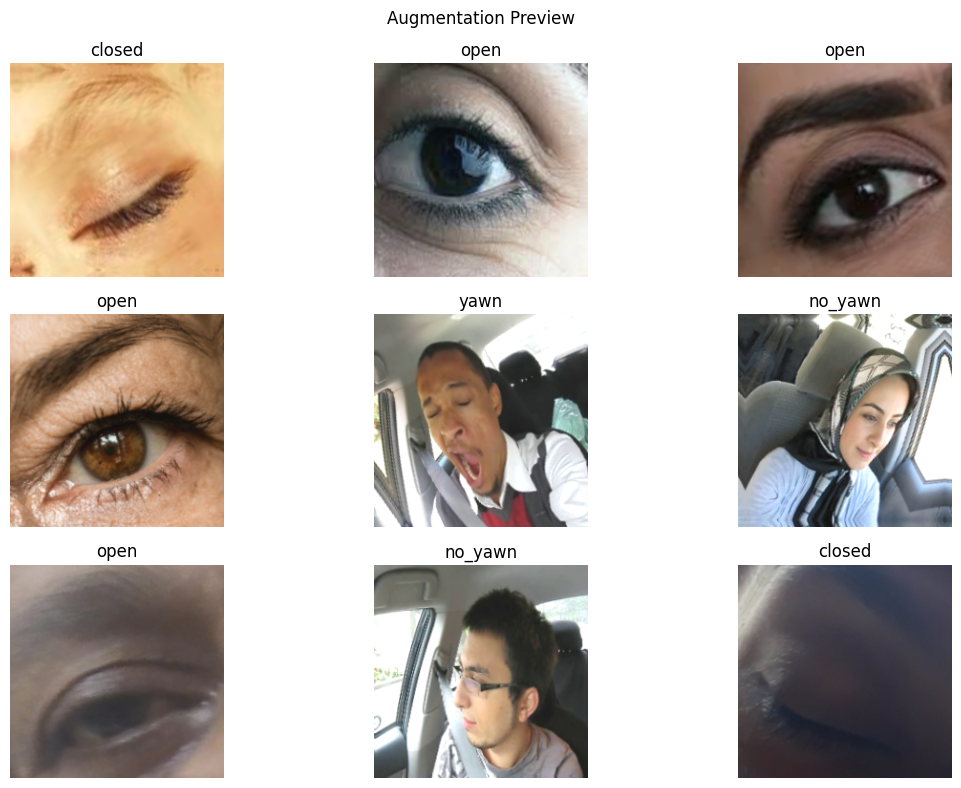

In [ ]:
# 4.3 Preprocessing and augmentation preview
augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
        layers.RandomBrightness(0.15, value_range=(0, 255)),
    ],
    name="data_augmentation"
)

sample_images, sample_labels = next(iter(train_all_ds))

augmented_images = augmentation(sample_images, training=True)

plt.figure(figsize=(12, 8))
for i in range(min(9, len(sample_images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(tf.cast(augmented_images[i], tf.uint8))
    label_idx = tf.argmax(sample_labels[i]).numpy()
    plt.title(EXPECTED_CLASSES[label_idx])
    plt.axis("off")

plt.suptitle("Augmentation Preview")
plt.tight_layout()
plt.show()


## **Step 5 — Model Selection**

Two approaches are compared as required:

### **Custom CNN**
Learns visual features directly from the project dataset.

### **MobileNetV2 Transfer Learning**
Uses ImageNet-pretrained feature extraction with the base layers frozen initially.

Both approaches are used independently for:

- Eye state: **Closed / Open**
- Mouth state: **No Yawn / Yawn**


## **Step 6 — Model Development**

The four binary models are:

1. Eye — Custom CNN
2. Eye — MobileNetV2
3. Mouth — Custom CNN
4. Mouth — MobileNetV2



In [ ]:
# 6.1 Binary dataset helpers
EYE_CLASSES = ["closed", "open"]
MOUTH_CLASSES = ["no_yawn", "yawn"]

def get_class_images(split_path, class_names):
    image_paths, labels = [], []

    for label, class_name in enumerate(class_names):
        folder = Path(split_path) / class_name

        for path in image_files(folder):
            image_paths.append(str(path))
            labels.append(label)

    return image_paths, labels

def load_raw_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)  # Keep 0-255 for model-specific preprocessing.
    return image, tf.cast(label, tf.float32)

def create_binary_dataset(image_paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    ds = ds.map(load_raw_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(
            buffer_size=max(1, len(image_paths)),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [ ]:
# 6.2 Create eye and mouth datasets
eye_train_paths, eye_train_labels = get_class_images(TRAIN_PATH, EYE_CLASSES)
eye_val_paths, eye_val_labels = get_class_images(VAL_PATH, EYE_CLASSES)
eye_test_paths, eye_test_labels = get_class_images(TEST_PATH, EYE_CLASSES)

mouth_train_paths, mouth_train_labels = get_class_images(TRAIN_PATH, MOUTH_CLASSES)
mouth_val_paths, mouth_val_labels = get_class_images(VAL_PATH, MOUTH_CLASSES)
mouth_test_paths, mouth_test_labels = get_class_images(TEST_PATH, MOUTH_CLASSES)

eye_train_ds = create_binary_dataset(eye_train_paths, eye_train_labels, shuffle=True)
eye_val_ds = create_binary_dataset(eye_val_paths, eye_val_labels)
eye_test_ds = create_binary_dataset(eye_test_paths, eye_test_labels)

mouth_train_ds = create_binary_dataset(mouth_train_paths, mouth_train_labels, shuffle=True)
mouth_val_ds = create_binary_dataset(mouth_val_paths, mouth_val_labels)
mouth_test_ds = create_binary_dataset(mouth_test_paths, mouth_test_labels)

print("Eye:", len(eye_train_paths), len(eye_val_paths), len(eye_test_paths))
print("Mouth:", len(mouth_train_paths), len(mouth_val_paths), len(mouth_test_paths))


Eye: 1016 218 218
Mouth: 1013 217 218


In [ ]:
# 6.3 Class distribution
print("EYE DISTRIBUTION")
print("Train:", Counter(eye_train_labels))
print("Validation:", Counter(eye_val_labels))
print("Test:", Counter(eye_test_labels))

print("\nMOUTH DISTRIBUTION")
print("Train:", Counter(mouth_train_labels))
print("Validation:", Counter(mouth_val_labels))
print("Test:", Counter(mouth_test_labels))


EYE DISTRIBUTION
Train: Counter({0: 508, 1: 508})
Validation: Counter({0: 109, 1: 109})
Test: Counter({0: 109, 1: 109})

MOUTH DISTRIBUTION
Train: Counter({0: 507, 1: 506})
Validation: Counter({0: 109, 1: 108})
Test: Counter({0: 109, 1: 109})


In [ ]:
# 6.4 Custom CNN
def build_custom_cnn():
    return models.Sequential(
        [
            layers.Input(shape=(224, 224, 3)),

            # Required augmentation, active only during training.
            augmentation,

            # Correct normalization for Custom CNN.
            layers.Rescaling(1.0 / 255.0),

            layers.Conv2D(32, 3, activation="relu", padding="same"),
            layers.MaxPooling2D(),

            layers.Conv2D(64, 3, activation="relu", padding="same"),
            layers.MaxPooling2D(),

            layers.Conv2D(128, 3, activation="relu", padding="same"),
            layers.MaxPooling2D(),

            layers.Conv2D(256, 3, activation="relu", padding="same"),
            layers.MaxPooling2D(),

            layers.GlobalAveragePooling2D(),

            layers.Dense(128, activation="relu"),
            layers.Dropout(0.5),

            layers.Dense(1, activation="sigmoid")
        ],
        name="custom_cnn"
    )

eye_custom_cnn = build_custom_cnn()
mouth_custom_cnn = build_custom_cnn()

eye_custom_cnn.summary()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 6.5 MobileNetV2 transfer learning
def build_mobilenetv2():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))

    # Augmentation operates on 0-255 images.
    x = augmentation(inputs)

    # MobileNetV2 expects its ImageNet preprocessing.
    x = layers.Lambda(preprocess_input, name="mobilenet_preprocess")(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="mobilenetv2_binary")

eye_mobilenet = build_mobilenetv2()
mouth_mobilenet = build_mobilenetv2()

print("Eye MobileNetV2:")
eye_mobilenet.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Eye MobileNetV2:


Model: "mobilenetv2_binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess (Lambda)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# 6.6 Verify frozen base layers
def print_trainable_status(model):
    base_layers = [
        layer for layer in model.layers
        if isinstance(layer, tf.keras.Model)
    ]

    for layer in base_layers:
        print(
            layer.name,
            "| trainable:",
            layer.trainable,
            "| parameters:",
            layer.count_params()
        )

print("Eye:")
print_trainable_status(eye_mobilenet)

print("\nMouth:")
print_trainable_status(mouth_mobilenet)


Eye:
data_augmentation | trainable: True | parameters: 0
mobilenetv2_1.00_224 | trainable: False | parameters: 2257984

Mouth:
data_augmentation | trainable: True | parameters: 0
mobilenetv2_1.00_224 | trainable: False | parameters: 2257984


## **Step 7 — Model Training**

The base MobileNetV2 layers are frozen and only the classification head is trained initially.

Training uses:

- Adam optimizer
- Binary cross-entropy
- Early stopping
- Validation monitoring

A fresh callback is created for each training run to avoid callback state being reused across models.


In [ ]:
# 7.1 Compile models
LEARNING_RATE = 1e-3
EPOCHS = 15

def compile_binary_model(model, learning_rate=LEARNING_RATE):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

for model in [
    eye_custom_cnn,
    eye_mobilenet,
    mouth_custom_cnn,
    mouth_mobilenet
]:
    compile_binary_model(model)

print("All models compiled.")


All models compiled.


In [ ]:
# 7.2 Train helper
def train_model(model, train_ds, val_ds, model_name, epochs=EPOCHS):
    callback = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )

    start = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[callback],
        verbose=1
    )

    elapsed = time.time() - start

    print(f"\n{model_name} training time: {elapsed:.2f} seconds")
    return history, elapsed


In [ ]:
# 7.3 Train all four models
eye_custom_history, eye_custom_time = train_model(
    eye_custom_cnn, eye_train_ds, eye_val_ds, "Eye Custom CNN"
)

eye_mobilenet_history, eye_mobilenet_time = train_model(
    eye_mobilenet, eye_train_ds, eye_val_ds, "Eye MobileNetV2"
)

mouth_custom_history, mouth_custom_time = train_model(
    mouth_custom_cnn, mouth_train_ds, mouth_val_ds, "Mouth Custom CNN"
)

mouth_mobilenet_history, mouth_mobilenet_time = train_model(
    mouth_mobilenet, mouth_train_ds, mouth_val_ds, "Mouth MobileNetV2"
)


Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 128ms/step - accuracy: 0.5207 - loss: 0.6950 - val_accuracy: 0.6147 - val_loss: 0.6909
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.5571 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6872
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.5423 - loss: 0.6900 - val_accuracy: 0.5459 - val_loss: 0.6864
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.6329 - loss: 0.6818 - val_accuracy: 0.6835 - val_loss: 0.6754
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.6447 - loss: 0.6468 - val_accuracy: 0.7064 - val_loss: 0.6707
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.7539 - loss: 0.5522 - val_accuracy: 0.7752 - val_loss: 0.5068
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.8248 - loss: 0.4555 - val_accuracy: 0.7752 - val_loss: 0.5601
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.8150 - loss: 0.4423 - val_accuracy: 0.8165 

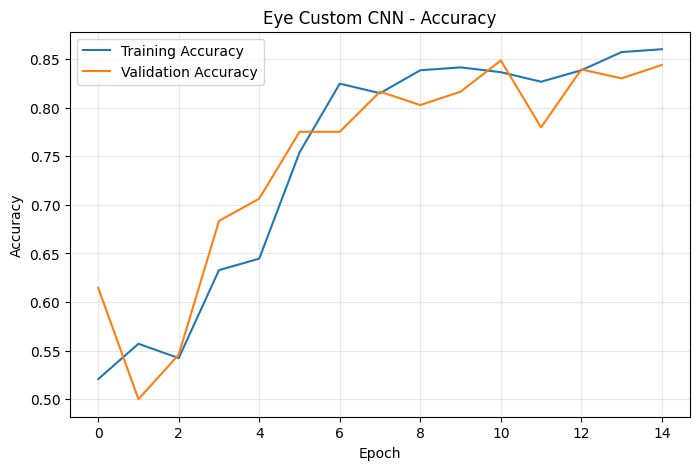

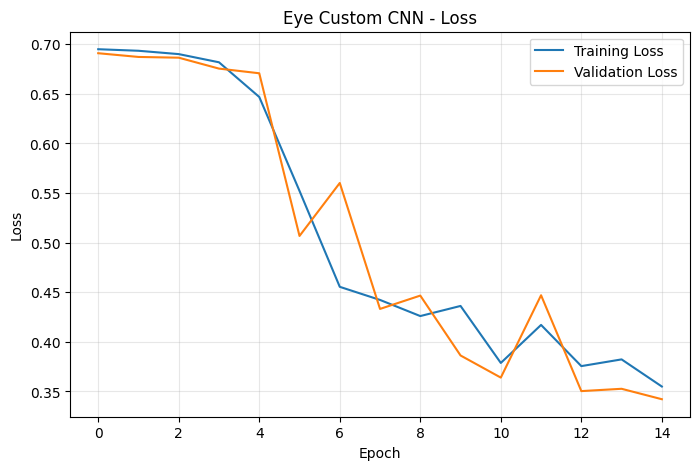

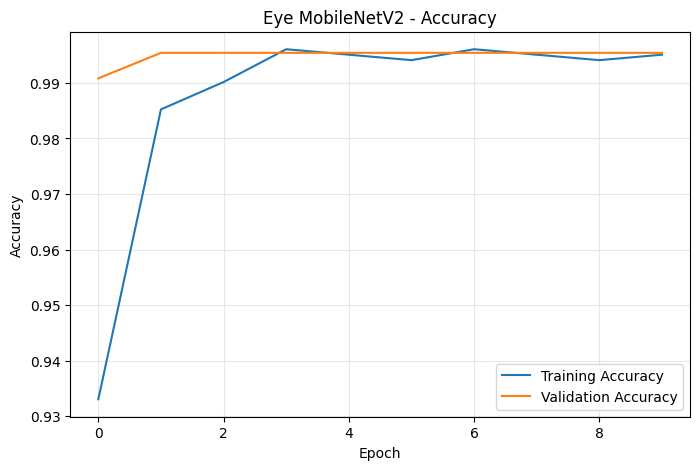

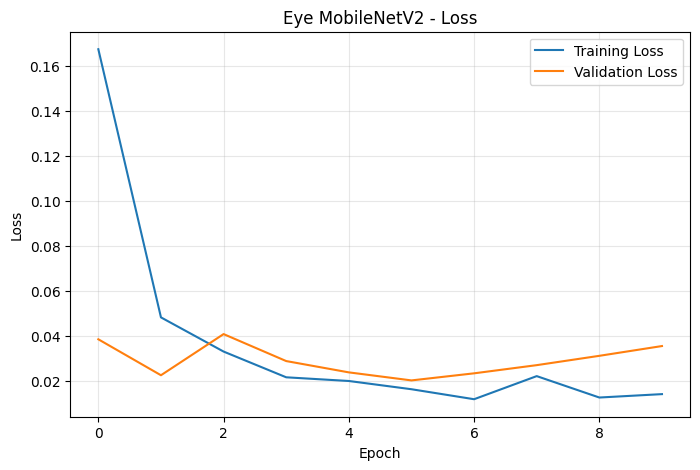

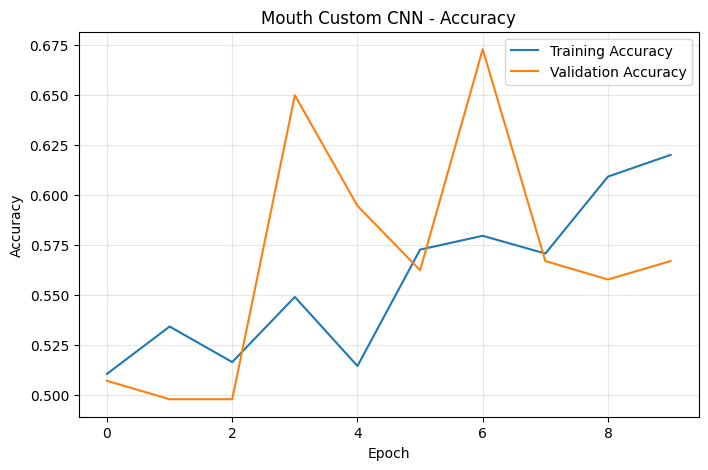

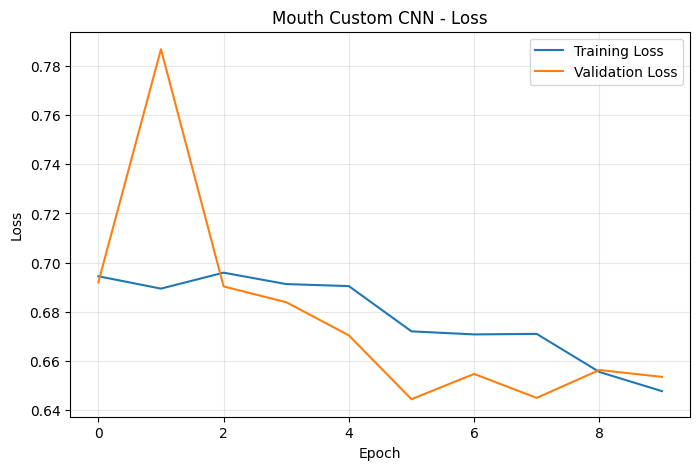

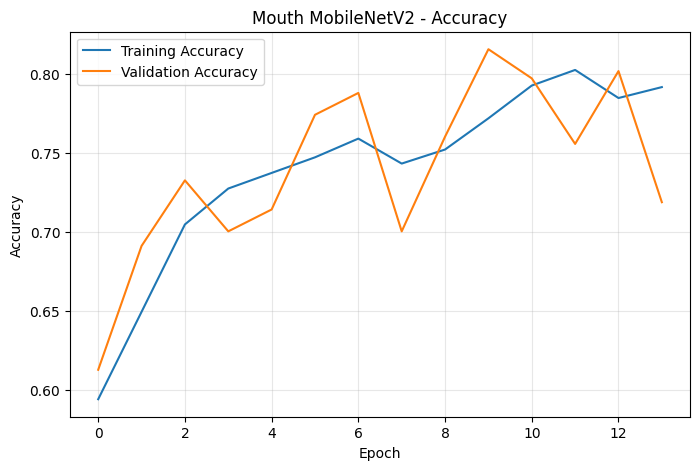

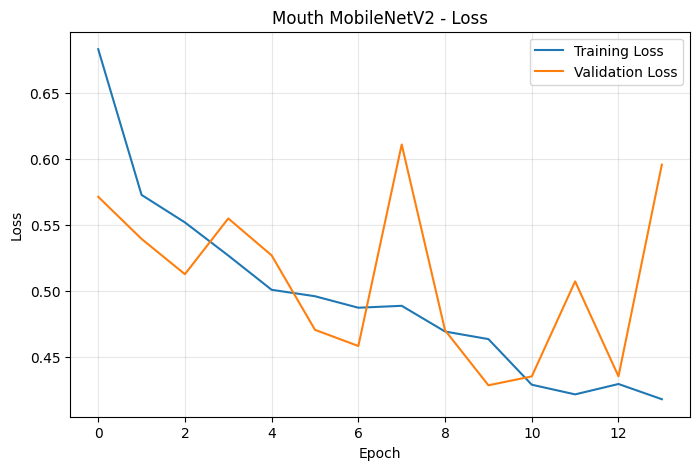

In [ ]:
# 7.4 Plot training history
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_loss(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

for h, name in [
    (eye_custom_history, "Eye Custom CNN"),
    (eye_mobilenet_history, "Eye MobileNetV2"),
    (mouth_custom_history, "Mouth Custom CNN"),
    (mouth_mobilenet_history, "Mouth MobileNetV2")
]:
    plot_history(h, f"{name} - Accuracy")
    plot_loss(h, f"{name} - Loss")


In [ ]:
# 7.5 Training-time comparison
training_time_df = pd.DataFrame({
    "Model": [
        "Eye Custom CNN",
        "Eye MobileNetV2",
        "Mouth Custom CNN",
        "Mouth MobileNetV2"
    ],
    "Training Time (seconds)": [
        eye_custom_time,
        eye_mobilenet_time,
        mouth_custom_time,
        mouth_mobilenet_time
    ]
})

display(training_time_df)


,Model,Training Time (seconds)
0,Eye Custom CNN,87.969901
1,Eye MobileNetV2,79.592982
2,Mouth Custom CNN,90.602779
3,Mouth MobileNetV2,114.914393


## **Step 8 — Model Evaluation**

Evaluation is performed only on unseen test data.

Metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix



Eye Custom CNN
              precision    recall  f1-score   support

      Closed       0.90      0.84      0.87       109
        Open       0.85      0.91      0.88       109

    accuracy                           0.88       218
   macro avg       0.88      0.88      0.88       218
weighted avg       0.88      0.88      0.88       218



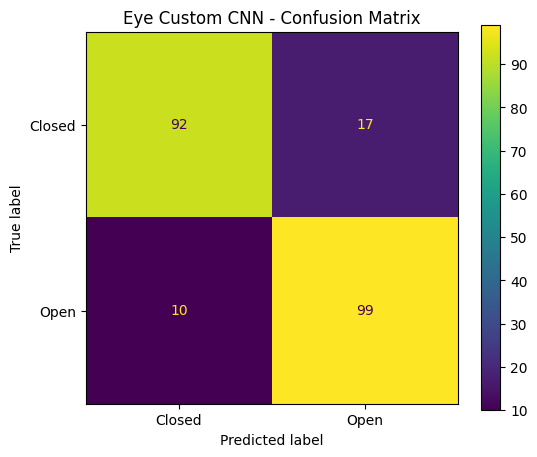


Eye MobileNetV2
              precision    recall  f1-score   support

      Closed       0.99      0.99      0.99       109
        Open       0.99      0.99      0.99       109

    accuracy                           0.99       218
   macro avg       0.99      0.99      0.99       218
weighted avg       0.99      0.99      0.99       218



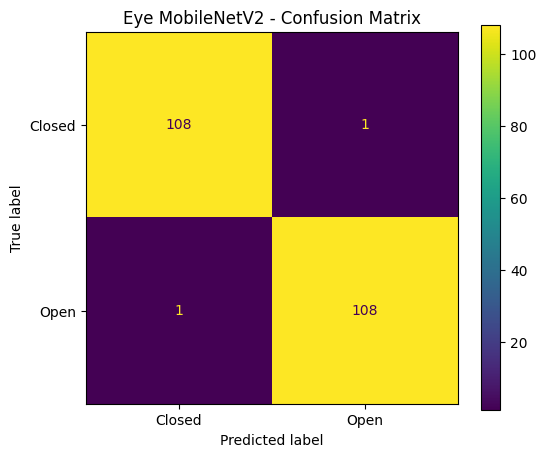


Mouth Custom CNN
              precision    recall  f1-score   support

     No Yawn       0.70      0.32      0.44       109
        Yawn       0.56      0.86      0.68       109

    accuracy                           0.59       218
   macro avg       0.63      0.59      0.56       218
weighted avg       0.63      0.59      0.56       218



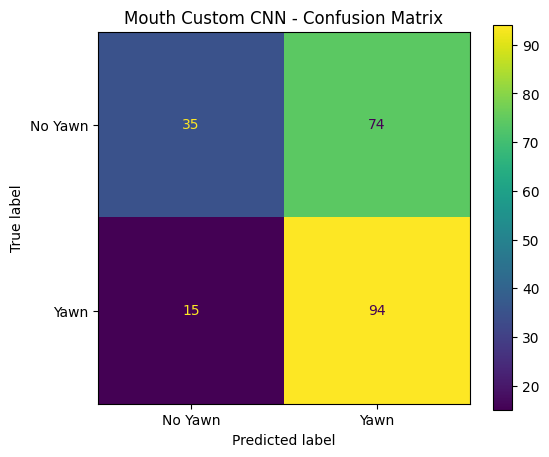


Mouth MobileNetV2
              precision    recall  f1-score   support

     No Yawn       0.67      0.90      0.77       109
        Yawn       0.85      0.56      0.67       109

    accuracy                           0.73       218
   macro avg       0.76      0.73      0.72       218
weighted avg       0.76      0.73      0.72       218



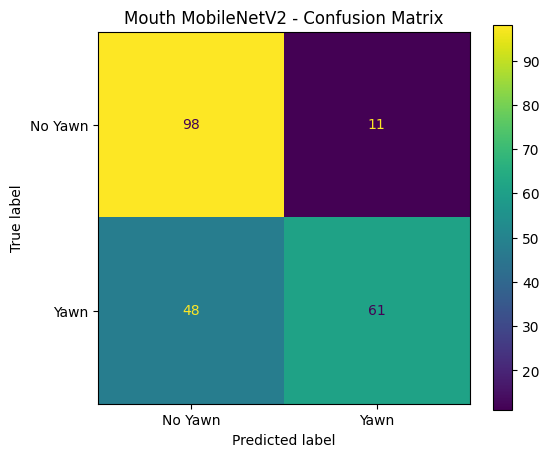

,Model,Accuracy,Precision,Recall,F1-Score
0,Eye Custom CNN,0.876147,0.853448,0.908257,0.880000
1,Eye MobileNetV2,0.990826,0.990826,0.990826,0.990826
2,Mouth Custom CNN,0.591743,0.559524,0.862385,0.678700
3,Mouth MobileNetV2,0.729358,0.847222,0.559633,0.674033


In [ ]:
# 8.1 Evaluation helpers
def get_predictions(model, dataset):
    y_true, y_prob = [], []

    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0).reshape(-1)

        y_true.extend(labels.numpy().astype(int))
        y_prob.extend(probabilities)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    return y_true, y_pred, y_prob

def evaluate_model(model, test_ds, class_names, model_name):
    y_true, y_pred, y_prob = get_predictions(model, test_ds)

    metrics_result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }

    print("\n" + "=" * 65)
    print(model_name)
    print("=" * 65)
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    ).plot(ax=ax, values_format="d")
    ax.set_title(f"{model_name} - Confusion Matrix")
    plt.show()

    return metrics_result, (y_true, y_pred, y_prob)

evaluation_rows = []
prediction_store = {}

model_specs = [
    ("Eye Custom CNN", eye_custom_cnn, eye_test_ds, ["Closed", "Open"]),
    ("Eye MobileNetV2", eye_mobilenet, eye_test_ds, ["Closed", "Open"]),
    ("Mouth Custom CNN", mouth_custom_cnn, mouth_test_ds, ["No Yawn", "Yawn"]),
    ("Mouth MobileNetV2", mouth_mobilenet, mouth_test_ds, ["No Yawn", "Yawn"]),
]

for name, model, ds, classes in model_specs:
    result, predictions = evaluate_model(model, ds, classes, name)
    evaluation_rows.append(result)
    prediction_store[name] = predictions

results_df = pd.DataFrame(evaluation_rows)
display(results_df)


In [ ]:
# 8.2 Percentage comparison table
results_percentage = results_df.copy()

metric_columns = ["Accuracy", "Precision", "Recall", "F1-Score"]
results_percentage[metric_columns] = (
    results_percentage[metric_columns] * 100
).round(2)

display(results_percentage)


,Model,Accuracy,Precision,Recall,F1-Score
0,Eye Custom CNN,87.61,85.34,90.83,88.00
1,Eye MobileNetV2,99.08,99.08,99.08,99.08
2,Mouth Custom CNN,59.17,55.95,86.24,67.87
3,Mouth MobileNetV2,72.94,84.72,55.96,67.40


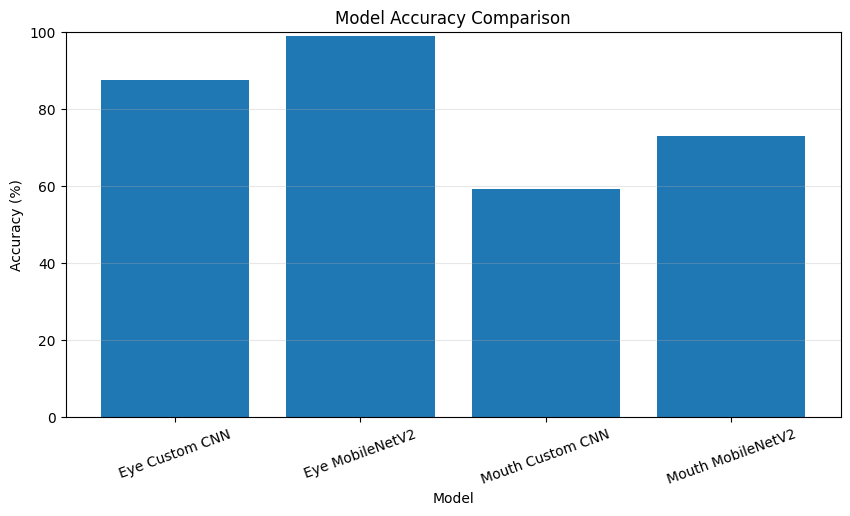

In [ ]:
# 8.3 Accuracy comparison
plt.figure(figsize=(10, 5))
plt.bar(
    results_percentage["Model"],
    results_percentage["Accuracy"]
)
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()


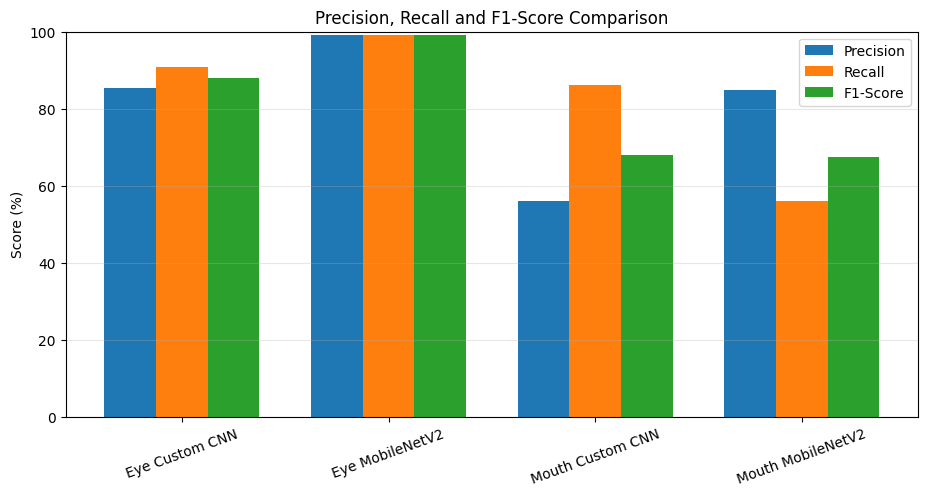

In [ ]:
# 8.4 Precision, Recall and F1 comparison
x = np.arange(len(results_percentage))
width = 0.25

plt.figure(figsize=(11, 5))

for i, metric in enumerate(["Precision", "Recall", "F1-Score"]):
    plt.bar(
        x + (i - 1) * width,
        results_percentage[metric],
        width,
        label=metric
    )

plt.xticks(x, results_percentage["Model"], rotation=20)
plt.ylabel("Score (%)")
plt.title("Precision, Recall and F1-Score Comparison")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


In [ ]:
# 8.5 Save evaluation outputs
RESULT_PATH = PROJECT_ROOT / "results"
MODEL_PATH = PROJECT_ROOT / "models"

RESULT_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH.mkdir(parents=True, exist_ok=True)

results_percentage.to_csv(
    RESULT_PATH / "model_evaluation_results.csv",
    index=False
)

training_time_df.to_csv(
    RESULT_PATH / "training_time_comparison.csv",
    index=False
)

# Save the four trained models.
eye_custom_cnn.save(MODEL_PATH / "eye_custom_cnn.keras")
eye_mobilenet.save(MODEL_PATH / "eye_mobilenetv2.keras")
mouth_custom_cnn.save(MODEL_PATH / "mouth_custom_cnn.keras")
mouth_mobilenet.save(MODEL_PATH / "mouth_mobilenetv2.keras")

print("Models and evaluation files saved.")


Models and evaluation files saved.


## **Dataset Leakage Check**

Exact duplicate checks are important because train/test leakage can produce unrealistically high performance.

The check below reports duplicate content across all three splits.


In [ ]:
# 8.6 Full duplicate check
all_hashes = {}

for split in ["train", "validation", "test"]:
    for cls in EXPECTED_CLASSES:
        for path in image_files(SPLIT_DIR / split / cls):
            h = md5_hash(path)
            all_hashes.setdefault(h, []).append((split, cls, str(path)))

cross_split_duplicates = [
    entries for entries in all_hashes.values()
    if len({item[0] for item in entries}) > 1
]

print("Cross-split duplicate groups:", len(cross_split_duplicates))

if cross_split_duplicates:
    print("WARNING: Duplicate image content exists across splits.")
else:
    print("No exact cross-split duplicates detected.")


Cross-split duplicate groups: 0
No exact cross-split duplicates detected.


# **Step 9 — Decision Fusion Logic**

The project requires three fatigue levels:

| Stage | Fatigue Level | Derived from |
|---:|---|---|
| 0 | Alert | Open + No Yawn |
| 1 | Mild Fatigue | Yawn |
| 2 | Severe Fatigue | Closed |

Priority is:

**Closed → Severe Fatigue**  
otherwise **Yawn → Mild Fatigue**  
otherwise **Alert**

This means `Closed + Yawn` is treated as **Severe Fatigue**, because eye closure has the higher severity priority.


In [ ]:
# 9.1 Fusion logic
FATIGUE_CLASSES = {
    0: "Alert",
    1: "Mild Fatigue",
    2: "Severe Fatigue"
}

def fatigue_decision(eye_state, mouth_state):
    if eye_state == "Closed":
        return 2, "Severe Fatigue"

    if mouth_state == "Yawn":
        return 1, "Mild Fatigue"

    return 0, "Alert"

def get_eye_state(probability):
    return "Open" if probability >= 0.5 else "Closed"

def get_mouth_state(probability):
    return "Yawn" if probability >= 0.5 else "No Yawn"

def predict_fatigue_stage(eye_probability, mouth_probability):
    eye_state = get_eye_state(eye_probability)
    mouth_state = get_mouth_state(mouth_probability)

    stage, label = fatigue_decision(
        eye_state,
        mouth_state
    )

    return {
        "Eye Probability": float(eye_probability),
        "Eye State": eye_state,
        "Mouth Probability": float(mouth_probability),
        "Mouth State": mouth_state,
        "Fatigue Stage": stage,
        "Fatigue Level": label
    }

test_cases = [
    ("Open", "No Yawn"),
    ("Open", "Yawn"),
    ("Closed", "No Yawn"),
    ("Closed", "Yawn")
]

for eye_state, mouth_state in test_cases:
    print(
        eye_state,
        "+",
        mouth_state,
        "->",
        fatigue_decision(eye_state, mouth_state)
    )


Open + No Yawn -> (0, 'Alert')
Open + Yawn -> (1, 'Mild Fatigue')
Closed + No Yawn -> (2, 'Severe Fatigue')
Closed + Yawn -> (2, 'Severe Fatigue')


### Important Fusion Limitation

The eye and mouth test datasets are independently stored. Unless each eye image and mouth image belongs to the **same original facial frame and is paired by an identifier**, simply zipping two test arrays does not create a scientifically valid frame-level fusion.




In [ ]:
# 9.2 Simulated fusion using aligned sequence length
eye_eval = prediction_store["Eye MobileNetV2"]
mouth_eval = prediction_store["Mouth MobileNetV2"]

eye_true, eye_pred, eye_prob = eye_eval
mouth_true, mouth_pred, mouth_prob = mouth_eval

n_fusion = min(len(eye_prob), len(mouth_prob))

if len(eye_prob) != len(mouth_prob):
    print(
        "WARNING: Eye and mouth test sets have different lengths. "
        f"Using the first {n_fusion} predictions for simulated fusion."
    )
else:
    print("Eye and mouth test sets have the same number of predictions.")

eye_prob_f = eye_prob[:n_fusion]
mouth_prob_f = mouth_prob[:n_fusion]

eye_states = np.array([get_eye_state(p) for p in eye_prob_f])
mouth_states = np.array([get_mouth_state(p) for p in mouth_prob_f])

fusion_rows = [
    predict_fatigue_stage(ep, mp)
    for ep, mp in zip(eye_prob_f, mouth_prob_f)
]

fusion_df = pd.DataFrame(fusion_rows)

display(fusion_df.head(10))


Eye and mouth test sets have the same number of predictions.


,Eye Probability,Eye State,Mouth Probability,Mouth State,Fatigue Stage,Fatigue Level
0,0.001950,Closed,0.132482,No Yawn,2,Severe Fatigue
1,0.000370,Closed,0.149838,No Yawn,2,Severe Fatigue
2,0.000011,Closed,0.368531,No Yawn,2,Severe Fatigue
3,0.000009,Closed,0.258885,No Yawn,2,Severe Fatigue
4,0.000109,Closed,0.245528,No Yawn,2,Severe Fatigue
5,0.000971,Closed,0.270238,No Yawn,2,Severe Fatigue
6,0.009247,Closed,0.143742,No Yawn,2,Severe Fatigue
7,0.000682,Closed,0.212621,No Yawn,2,Severe Fatigue
8,0.043493,Closed,0.156520,No Yawn,2,Severe Fatigue
9,0.000078,Closed,0.252188,No Yawn,2,Severe Fatigue


In [ ]:
# 9.3 Fatigue distribution
fatigue_distribution = (
    fusion_df["Fatigue Level"]
    .value_counts()
    .reindex(
        ["Alert", "Mild Fatigue", "Severe Fatigue"],
        fill_value=0
    )
)

fatigue_percentage = (
    fatigue_distribution / len(fusion_df) * 100
).round(2)

fusion_summary = pd.DataFrame({
    "Count": fatigue_distribution,
    "Percentage": fatigue_percentage
})

display(fusion_summary)

fusion_df.to_csv(
    RESULT_PATH / "fatigue_fusion_results.csv",
    index=False
)

fusion_summary.to_csv(
    RESULT_PATH / "fatigue_fusion_summary.csv"
)


,Count,Percentage
Fatigue Level,,
Alert,48,22.02
Mild Fatigue,61,27.98
Severe Fatigue,109,50.00


# Step 10 — Driver Fatigue Progression Curve

The project asks for sequential predictions grouped into time intervals.

Because a static test dataset is not a real driving session, this section uses a **simulated sequence**. `FRAMES_PER_MINUTE` is configurable.

The transition analysis detects actual category changes instead of simply reporting the first minute above a numeric threshold.


In [ ]:
# 10.1 Build simulated time sequence
FRAMES_PER_MINUTE = 10

progression_df = fusion_df.copy()
progression_df.insert(
    0,
    "Frame",
    np.arange(1, len(progression_df) + 1)
)

progression_df["Time Interval"] = (
    (progression_df["Frame"] - 1)
    // FRAMES_PER_MINUTE
) + 1

progression_df.head(15)


,Frame,Eye Probability,Eye State,Mouth Probability,Mouth State,Fatigue Stage,Fatigue Level,Time Interval
0,1,0.001950,Closed,0.132482,No Yawn,2,Severe Fatigue,1
1,2,0.000370,Closed,0.149838,No Yawn,2,Severe Fatigue,1
2,3,0.000011,Closed,0.368531,No Yawn,2,Severe Fatigue,1
3,4,0.000009,Closed,0.258885,No Yawn,2,Severe Fatigue,1
4,5,0.000109,Closed,0.245528,No Yawn,2,Severe Fatigue,1
5,6,0.000971,Closed,0.270238,No Yawn,2,Severe Fatigue,1
6,7,0.009247,Closed,0.143742,No Yawn,2,Severe Fatigue,1
7,8,0.000682,Closed,0.212621,No Yawn,2,Severe Fatigue,1
8,9,0.043493,Closed,0.156520,No Yawn,2,Severe Fatigue,1
9,10,0.000078,Closed,0.252188,No Yawn,2,Severe Fatigue,1


In [ ]:
# 10.2 Calculate average stage per interval
minute_summary = (
    progression_df
    .groupby("Time Interval", as_index=False)
    .agg(
        Average_Fatigue_Stage=("Fatigue Stage", "mean"),
        Frames=("Frame", "count")
    )
)

def stage_to_level(stage):
    if stage < 0.5:
        return "Alert"
    elif stage < 1.5:
        return "Mild Fatigue"
    return "Severe Fatigue"

minute_summary["Fatigue Level"] = (
    minute_summary["Average_Fatigue_Stage"]
    .apply(stage_to_level)
)

display(minute_summary)


,Time Interval,Average_Fatigue_Stage,Frames,Fatigue Level
0,1,2.0,10,Severe Fatigue
1,2,1.8,10,Severe Fatigue
2,3,2.0,10,Severe Fatigue
3,4,2.0,10,Severe Fatigue
4,5,2.0,10,Severe Fatigue
5,6,2.0,10,Severe Fatigue
6,7,2.0,10,Severe Fatigue
7,8,2.0,10,Severe Fatigue
8,9,2.0,10,Severe Fatigue
9,10,2.0,10,Severe Fatigue


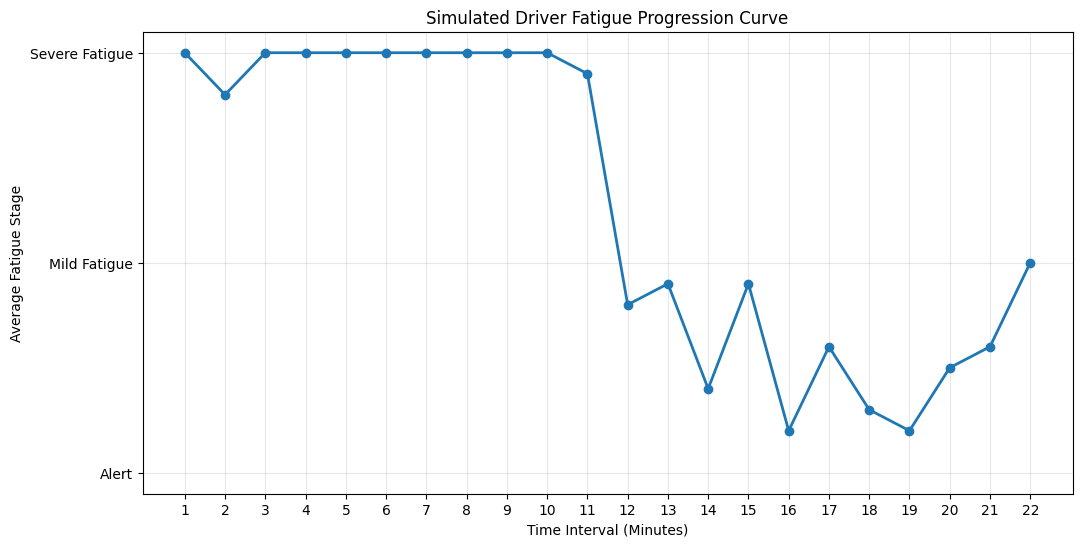

In [ ]:
# 10.3 Fatigue progression curve
plt.figure(figsize=(12, 6))

plt.plot(
    minute_summary["Time Interval"],
    minute_summary["Average_Fatigue_Stage"],
    marker="o",
    linewidth=2
)

plt.xlabel("Time Interval (Minutes)")
plt.ylabel("Average Fatigue Stage")
plt.title("Simulated Driver Fatigue Progression Curve")

plt.yticks(
    [0, 1, 2],
    ["Alert", "Mild Fatigue", "Severe Fatigue"]
)

plt.ylim(-0.1, 2.1)
plt.xticks(minute_summary["Time Interval"])
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# 10.4 Correct transition detection
previous_level = None
transitions = []

for _, row in minute_summary.iterrows():
    current_level = row["Fatigue Level"]
    current_minute = int(row["Time Interval"])

    if previous_level is not None and current_level != previous_level:
        transitions.append({
            "Minute": current_minute,
            "From": previous_level,
            "To": current_level
        })

    previous_level = current_level

transition_df = pd.DataFrame(transitions)

print("========== ACTUAL CATEGORY TRANSITIONS ==========")

if transition_df.empty:
    print("No category transitions detected in this simulated sequence.")
else:
    display(transition_df)

minute_summary.to_csv(
    RESULT_PATH / "fatigue_progression.csv",
    index=False
)

transition_df.to_csv(
    RESULT_PATH / "fatigue_transitions.csv",
    index=False
)


========== ACTUAL CATEGORY TRANSITIONS ==========


,Minute,From,To
0,12,Severe Fatigue,Mild Fatigue
1,14,Mild Fatigue,Alert
2,15,Alert,Mild Fatigue
3,16,Mild Fatigue,Alert
4,17,Alert,Mild Fatigue
5,18,Mild Fatigue,Alert
6,20,Alert,Mild Fatigue


## **Interpreting the Progression Curve**

A valid interpretation must be based on the generated `minute_summary` and `transition_df`.

Do **not** write that the driver naturally progressed from Alert → Mild Fatigue → Severe Fatigue unless the curve actually shows those transitions in chronological order.

For this project, the sequence is simulated from test predictions; therefore, the result demonstrates the requested processing logic rather than proving real-time physiological fatigue progression.


# **Step 11 — Performance Analysis**

The final analysis includes:

1. Custom CNN vs MobileNetV2 accuracy
2. Precision, recall and F1-score
3. Training time
4. Class-level performance
5. Confusion matrices
6. Robustness considerations
7. Error cases
8. Decision-fusion limitation


In [ ]:
# 11.1 Eye vs Mouth comparison
comparison = pd.DataFrame({
    "Task": ["Eye State", "Mouth State"],
    "Custom CNN Accuracy": [
        results_percentage.loc[
            results_percentage["Model"] == "Eye Custom CNN",
            "Accuracy"
        ].iloc[0],
        results_percentage.loc[
            results_percentage["Model"] == "Mouth Custom CNN",
            "Accuracy"
        ].iloc[0]
    ],
    "MobileNetV2 Accuracy": [
        results_percentage.loc[
            results_percentage["Model"] == "Eye MobileNetV2",
            "Accuracy"
        ].iloc[0],
        results_percentage.loc[
            results_percentage["Model"] == "Mouth MobileNetV2",
            "Accuracy"
        ].iloc[0]
    ]
})

comparison["Improvement (percentage points)"] = (
    comparison["MobileNetV2 Accuracy"]
    - comparison["Custom CNN Accuracy"]
)

display(comparison)


,Task,Custom CNN Accuracy,MobileNetV2 Accuracy,Improvement (percentage points)
0,Eye State,87.61,99.08,11.47
1,Mouth State,59.17,72.94,13.77


In [ ]:
# 11.2 Best model for each task
best_models = []

for task, names in {
    "Eye State": ["Eye Custom CNN", "Eye MobileNetV2"],
    "Mouth State": ["Mouth Custom CNN", "Mouth MobileNetV2"]
}.items():

    subset = results_percentage[
        results_percentage["Model"].isin(names)
    ].sort_values("Accuracy", ascending=False)

    best_models.append({
        "Task": task,
        "Best Model": subset.iloc[0]["Model"],
        "Test Accuracy (%)": subset.iloc[0]["Accuracy"],
        "Precision (%)": subset.iloc[0]["Precision"],
        "Recall (%)": subset.iloc[0]["Recall"],
        "F1 (%)": subset.iloc[0]["F1-Score"]
    })

best_models_df = pd.DataFrame(best_models)
display(best_models_df)


,Task,Best Model,Test Accuracy (%),Precision (%),Recall (%),F1 (%)
0,Eye State,Eye MobileNetV2,99.08,99.08,99.08,99.08
1,Mouth State,Mouth MobileNetV2,72.94,84.72,55.96,67.40


### Robustness and Error Cases

The system may be affected by:

- Low or changing illumination
- Head rotation and unusual camera angles
- Occluded eyes or mouth
- Glasses or reflections
- Facial-expression variation
- Poor image quality
- Camera placement
- Differences between training images and real-world drivers

These are limitations of an image-based drowsiness system and should be discussed in the final presentation.
